# 卷积神经网络 (LeNet)

## LeNet (LeNet-5) 由两个部分组成：卷积编码器和全连接层密集块

In [ ]:
# 导包
import torch
from torch import nn
from d2l import torch as d2l

from pytorch.Day22.linear_regression import optimizer


class Reshape(nn.Module):
    """
    为什么需要这个层？
        在 LeNet 网络中，输入可能已经被展平成一维向量，例如形状 (batch_size, 784)。
        但卷积层 nn.Conv2d 需要输入是四维张量 (batch_size, channels, height, width)。
        所以需要先用 Reshape 把 (batch_size, 784) 变成 (batch_size, 1, 28, 28)，才能送入卷积层。
    """
    def forward(self, x):
        # 参1：-1表示自动推断这一维的大小，通常是batch size；参2：通道数，1表示是灰度图；参3：高度；参4：宽度
        return x.view(-1, 1, 28, 28)            # view是PyTorch中用来改变张量形状的方法，要求元素总数不变

net = nn.Sequential(
    # 将输入重塑为 (batch_size, 1, 28, 28) 的灰度图像格式
    Reshape(),
    # 卷积层1：输入：(N， 1， 28， 28) -> 输出：(N, 6, 28, 28)
    nn.Conv2d(1, 6, kernel_size = 5, padding = 2),
    nn.Sigmoid(),       # Sigmoid激活函数，为了引入非线性，让网络能学习复杂模式
    # 平均池化层1：输入：(N, 6, 28, 28) -> 输出：(N, 6, 14, 14)
    nn.AvgPool2d(kernel_size = 2, stride = 2),
    # 卷积层2：输入：(N, 6, 14, 14) -> 输出：(N, 16, 10, 10)
    nn.Conv2d(6, 16, kernel_size = 5),
    nn.Sigmoid(),       # Sigmoid激活函数
    # 平均池化层2：输入：(N, 16, 10, 10) -> 输出：(N, 16, 5, 5)
    nn.AvgPool2d(kernel_size = 2, stride = 2),
    # 展平层：输入：(N, 16, 5, 5) -> 输出：(N, 16 * 5 * 5) = (N, 400)
    nn.Flatten(),
    # 全连接层1：输入：(N, 400) -> 输出：(N, 120)
    nn.Linear(16 * 5 * 5, 120),
    nn.Sigmoid(),
    # 全连接层2：输入：(N, 120) -> 输出：(N, 84)
    nn.Linear(120, 84),
    nn.Sigmoid(),
    # 输出层：输入：(N, 84) -> 输出：(N, 10)，这里的10就是最后的类别数量（如数字0-9）
    nn.Linear(84, 10)
)

## 检查模型

In [13]:
X = torch.rand(size = (1, 1, 28, 28), dtype = torch.float32)
for layer in net:       # 因为net是Sequential构造，所以每层可以一一拿出来遍历
    X = layer(X)
    print(layer.__class__.__name__, 'output shape: \t', X.shape)

Reshape output shape: 	 torch.Size([1, 1, 28, 28])
Conv2d output shape: 	 torch.Size([1, 6, 28, 28])
Sigmoid output shape: 	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape: 	 torch.Size([1, 6, 14, 14])
Conv2d output shape: 	 torch.Size([1, 16, 10, 10])
Sigmoid output shape: 	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape: 	 torch.Size([1, 16, 5, 5])
Flatten output shape: 	 torch.Size([1, 400])
Linear output shape: 	 torch.Size([1, 120])
Sigmoid output shape: 	 torch.Size([1, 120])
Linear output shape: 	 torch.Size([1, 84])
Sigmoid output shape: 	 torch.Size([1, 84])
Linear output shape: 	 torch.Size([1, 10])


## LeNet在Fashion-MNIST数据集上的表现

In [17]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size = batch_size)

100.0%
100.0%
100.0%


## 对`evaluate_accuracy`函数进行轻微的修改

In [18]:
def evaluate_accuracy_gpu(net, data_iter, device = None):
    """
    使用GPU计算模型在数据集上的精度
    参数：
        net：要评估的模型，通常是 nn.Module 的子类。
        data_iter：数据迭代器，每次产出一个批次 (X, y)。
        device：可选参数，指定计算设备（如 cuda:0 或 cpu）。如果不传，会尝试从模型参数中推断。
    """
    if isinstance(net, nn.Module):
        net.eval()      # 测试模式
        if not device:
            # 如果device没有指定，就从模型的第一个参数中获取它所在的设备。next(iter(net.parameters()))取出第一个参数张量， .device得到设备。
            device = next(iter(net.parameters())).device        # 如果没传device，就自行从模型参数中推断
    metric = d2l.Accumulator(2)      # 累加器，这里初始化两个槽位，用于存储：metric[0]正确预测数和metric[1]预测总数
    for X, y in data_iter:
        if isinstance(X, list):
            X = [x.to(device) for x in X]
        else:
            X = X.to(device)
        y = y.to(device)
        metric.add(d2l.accuracy(net(X), y), y.numel())          # 把这两个值分别累加到 metric[0]和metric[1]
    return metric[0] / metric[1]        # 总正确数除以总样本数，得到整个数据集上的准确率。

## 为了使用GPU，我们还需要一点小改动

In [19]:
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """使用GPU训练模型"""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform(m.weight)        # Xavier均匀分布初始化
    net.apply(init_weights)
    print(f"训练在{device}上进行")
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr = lr)
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel = 'epoch', xlim = [1, num_epochs],
                            legend = ['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)
    for epoch in range(num_epochs):
        metric = d2l.Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f"loss:{train_l:.3f}, train_acc:{train_acc:.3f}, test_acc:{test_acc:.3f}")
    print(f"{metric[2] * num_epochs / timer.sum():.1f} examples/sec on {str(device)}")

## 训练和评估LeNet-5模型

loss:0.481, train_acc:0.818, test_acc:0.796
19162.1 examples/sec on cpu


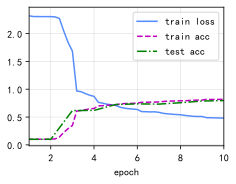

In [20]:
lr, num_epochs = 0.9, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())